# 13 — Temporal model benchmark

**Question.** Is the production model choice (tuned XGBoost) defensible against simpler and alternative models when every model is judged on the *same* future-period data?

**What can and cannot be concluded.** Under the same temporal holdout and feature framework, the tested models produced the observed performance below. This is **not** evidence of global model superiority: training configurations differ by model, only XGBoost was tuned, and the Random Forest ran in a resource-constrained configuration.

The production model is **not** changed by this notebook.

## Protocol

| | Shared by every model | Differs by model |
|---|---|---|
| Test population | `outputs/kkbox_modeling_dataset_v2.csv` — `train_v2.csv`, March-2017 churn, features cut off 2017-02-28. **All 970,960 customers, never subsampled.** | — |
| Training data | `outputs/kkbox_modeling_dataset_v1_temporal_train.csv` — `train.csv`, February-2017 churn, features cut off 2017-01-31 (written by notebook 05) | Random Forest uses a stratified 300,000-row sample of it |
| Features | Notebook 05's full feature set and preprocessing (median impute + scale, one-hot), fitted on the training data | — |
| Metrics | PR-AUC (primary), ROC-AUC, Brier, Precision / Recall at the top 2.3% | — |
| Training configuration | — | See the run table below |

- **Operating point.** The top 22,692 customers = 2.337% of the holdout = the size of the production High-risk tier (`risk_scoring_summary.json`).
- **Not compared:** fixed-threshold precision / recall / F1. The models' raw score scales differ (class weighting, `scale_pos_weight`), so one shared 0.5 cut-off means different things for different models.
- **Tuned XGBoost is not retrained.** Its holdout scores are the production model's own (`outputs/risk_scoring_predictions.csv`, notebook 06), checked against notebook 05's published ROC-AUC 0.8696 / PR-AUC 0.5432 before use.
- **Earlier benchmark attempts were invalid and discarded** (a float32 load rounded the date features; a later run was stopped for memory). None of their numbers are used here.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import model_benchmark as mb

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

## How the scores were produced

Each model was run as its own process, **sequentially**, with a free-memory check before training and its holdout scores saved the moment it finished (`src/model_benchmark.py`; completed models are never re-run):

```
python -m src.model_benchmark --step holdout
python -m src.model_benchmark --step rule_auto_renew_off
python -m src.model_benchmark --step xgboost_tuned
python -m src.model_benchmark --step logistic_regression
python -m src.model_benchmark --step lightgbm
python -m src.model_benchmark --step random_forest
python -m src.model_benchmark --step bootstrap
```

To fit in memory, the preprocessed training matrix is held sparse in float32 and the holdout is scored in 100,000-row chunks. Raw features stay float64 (the yyyymmdd date features exceed float32's integer precision). On a 50,000-row check this matches notebook 05's dense float64 preprocessing to within 3e-6.

**Random Forest is resource-constrained:** 150 trees, `max_depth=16`, `min_samples_leaf=20`, `n_jobs=2`, trained on a stratified 300,000-row sample. It is **not** the 200-tree, full-training-set Random Forest of notebook 03's random-split experiment.

In [2]:
runs = pd.DataFrame([json.loads((mb.OUT_DIR / f"{m}.json").read_text()) for m in mb.MODEL_SPECS])
runs[["label", "status", "train_rows_used", "test_rows", "fit_seconds", "score_seconds", "training_config"]]

,label,status,train_rows_used,test_rows,fit_seconds,score_seconds,training_config
0,Rule: auto-renew off,completed,992931,970960,0.0,3.4,"flag = latest_is_auto_renew == 0 (missing -> training median, as the preprocessor imputes); score = the training-set..."
1,Logistic Regression,completed,992931,970960,42.6,9.9,"LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42) -- notebook 02's settings; full temporal..."
2,LightGBM,completed,992931,970960,34.8,18.5,"LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, max_depth=8, min_child_samples=100, subsample=0...."
3,Random Forest (resource-constrained),completed,300000,970960,65.1,19.1,"RandomForestClassifier(n_estimators=150, max_depth=16, min_samples_leaf=20, max_features='sqrt', class_weight='balan..."
4,"XGBoost (tuned, production)",completed,992931,970960,NaN,4.5,"models/xgboost_temporal_full.joblib -- hyperparameters tuned in notebook 04 (random split), refit on the temporal tr..."


## Results on the temporal holdout

`brier` is the raw model score's Brier score on the full holdout. Class weighting inflates raw scores, so for the weighted models it mostly measures miscalibration of the raw output. `brier_after_isotonic` puts every model on the same footing: an isotonic calibrator fitted on notebook 10's `calib_fit` half, evaluated on its `calib_eval` half.

In [3]:
results = mb.evaluate()   # writes outputs/model_benchmark_results.csv and outputs/model_benchmark_summary.json
metric_cols = ["model", "pr_auc", "roc_auc", "brier", "brier_after_isotonic", "precision_at_2_3pct", "recall_at_2_3pct",
               "train_rows_used", "test_rows", "fit_seconds"]
display(results[metric_cols].style.format({c: "{:.4f}" for c in metric_cols[1:7]} | {"train_rows_used": "{:,.0f}", "test_rows": "{:,.0f}", "fit_seconds": "{:.1f}"}, na_rep="—").hide(axis="index"))
y = np.load(mb.OUT_DIR / "holdout.npz")["y"]
print(f"Holdout: {len(y):,} customers, churn rate {y.mean():.4f}  |  every model scored on all of them: {set(results['test_rows']) == {len(y)}}")

model,pr_auc,roc_auc,brier,brier_after_isotonic,precision_at_2_3pct,recall_at_2_3pct,train_rows_used,test_rows,fit_seconds
Random Forest (resource-constrained),0.5498,0.8753,0.1150,0.0561,0.8117,0.2109,"300,000","970,960",65.1
"XGBoost (tuned, production)",0.5432,0.8696,0.1179,0.0567,0.8001,0.2079,"992,931","970,960",—
Logistic Regression,0.5234,0.8543,0.1209,0.0569,0.7550,0.1962,"992,931","970,960",42.6
LightGBM,0.5162,0.8669,0.1208,0.0580,0.7248,0.1883,"992,931","970,960",34.8
Rule: auto-renew off,0.2626,0.7306,0.0693,0.0681,0.4113,0.1069,"992,931","970,960",0.0


Holdout: 970,960 customers, churn rate 0.0899  |  every model scored on all of them: True


### Is a PR-AUC difference larger than the noise in the holdout?

A paired bootstrap over holdout rows (500 Poisson resamples; each resample reweights the same rows for every model) gives a 95% interval for each model's PR-AUC minus the production XGBoost's. **It captures holdout sampling uncertainty only.** Each model was trained once, so the effect of a different training seed or Random Forest sample is not included.

In [4]:
boot = json.loads((mb.OUT_DIR / "bootstrap_pr_auc_vs_xgboost.json").read_text())["differences"]
labels = {k: v["label"] for k, v in mb.MODEL_SPECS.items()}
pd.DataFrame([{"model": labels[k], "PR-AUC minus production XGBoost": v["observed_diff"],
               "95% low": v["ci95_low"], "95% high": v["ci95_high"]} for k, v in boot.items()]
            ).sort_values("PR-AUC minus production XGBoost", ascending=False).style.format(
    {"PR-AUC minus production XGBoost": "{:+.4f}", "95% low": "{:+.4f}", "95% high": "{:+.4f}"}).hide(axis="index")

model,PR-AUC minus production XGBoost,95% low,95% high
Random Forest (resource-constrained),+0.0066,+0.0052,+0.0082
Logistic Regression,-0.0198,-0.0220,-0.0173
LightGBM,-0.0270,-0.0286,-0.0253
Rule: auto-renew off,-0.2806,-0.2833,-0.2781


## Comparison charts

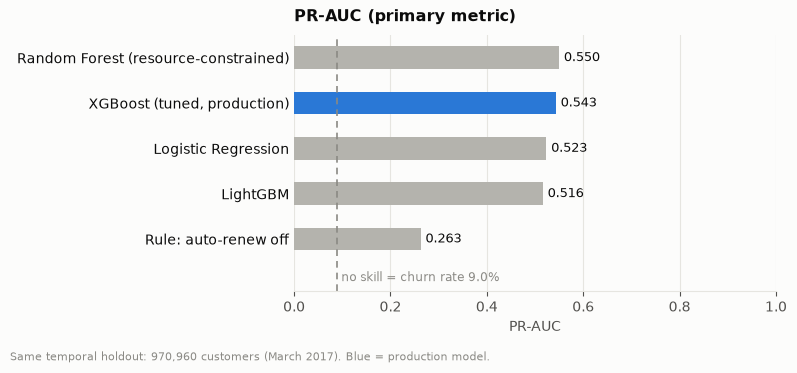

In [5]:
PLOT_DIR = mb.config.OUTPUT_DIR / "model_benchmark_plots"
PLOT_DIR.mkdir(exist_ok=True)

SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e0"
PRODUCTION, OTHER = "#2a78d6", "#b4b3ad"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "axes.edgecolor": GRID,
                     "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK})

done = results[results["status"] == "completed"]
churn_rate = float(y.mean())


def bar_chart(metric, title, xlabel, ref=None, ref_label=None, fname=None):
    d = done.sort_values(metric)
    colors = [PRODUCTION if k == "xgboost_tuned" else OTHER for k in d["model_key"]]
    fig, ax = plt.subplots(figsize=(8, 3.7), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    ax.barh(d["model"], d[metric], height=0.5, color=colors)
    for i, v in enumerate(d[metric]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", color=INK, fontsize=9.5)
    if ref is not None:
        ax.axvline(ref, color=MUTED, lw=1.2, ls=(0, (4, 3)))
        ax.text(ref + 0.008, -0.85, ref_label, color=MUTED, fontsize=8.5, va="center")
    ax.set_ylim(-1.15, len(d) - 0.5)
    ax.set_xlim(0, 1)
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", color=INK, fontsize=11.5, fontweight="bold", pad=10)
    ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.text(0.01, 0.01, f"Same temporal holdout: {len(y):,} customers (March 2017). Blue = production model.",
             color=MUTED, fontsize=8)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(PLOT_DIR / fname, dpi=200, facecolor=SURFACE)
    plt.show()


bar_chart("pr_auc", "PR-AUC (primary metric)", "PR-AUC", ref=churn_rate,
          ref_label=f"no skill = churn rate {churn_rate:.1%}", fname="pr_auc.png")

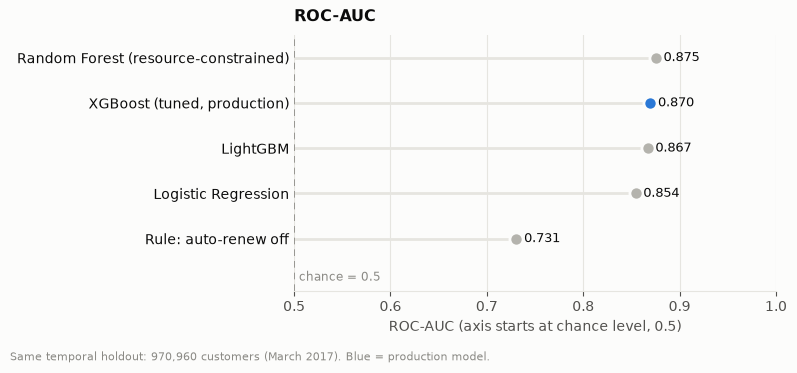

In [6]:
d = done.sort_values("roc_auc")
fig, ax = plt.subplots(figsize=(8, 3.7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for i, (k, v) in enumerate(zip(d["model_key"], d["roc_auc"])):
    c = PRODUCTION if k == "xgboost_tuned" else OTHER
    ax.plot([0.5, v], [i, i], color=GRID, lw=2, zorder=1)
    ax.scatter(v, i, s=90, color=c, edgecolor=SURFACE, linewidth=2, zorder=3)
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", color=INK, fontsize=9.5)
ax.set_yticks(range(len(d)), d["model"])
ax.axvline(0.5, color=MUTED, lw=1.2, ls=(0, (4, 3)))
ax.text(0.505, -0.85, "chance = 0.5", color=MUTED, fontsize=8.5, va="center")
ax.set_ylim(-1.15, len(d) - 0.5)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("ROC-AUC (axis starts at chance level, 0.5)")
ax.set_title("ROC-AUC", loc="left", color=INK, fontsize=11.5, fontweight="bold", pad=10)
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.text(0.01, 0.01, f"Same temporal holdout: {len(y):,} customers (March 2017). Blue = production model.", color=MUTED, fontsize=8)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(PLOT_DIR / "roc_auc.png", dpi=200, facecolor=SURFACE)
plt.show()

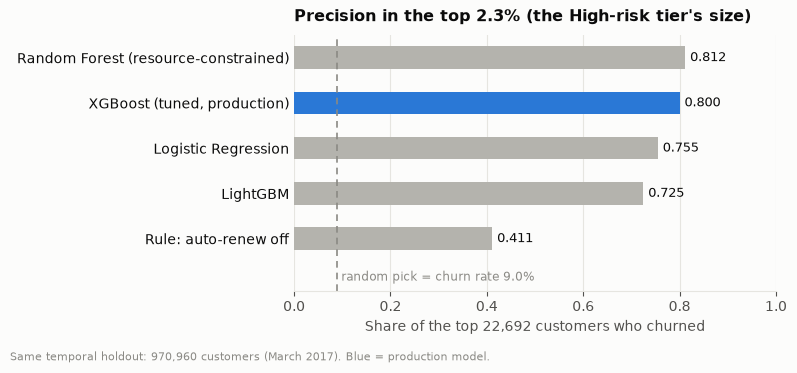

saved: ['pr_auc.png', 'precision_at_2_3pct.png', 'roc_auc.png']


In [7]:
bar_chart("precision_at_2_3pct", "Precision in the top 2.3% (the High-risk tier's size)",
          "Share of the top 22,692 customers who churned", ref=churn_rate,
          ref_label=f"random pick = churn rate {churn_rate:.1%}", fname="precision_at_2_3pct.png")
print("saved:", sorted(p.name for p in PLOT_DIR.glob("*.png")))

## What was observed

All figures are on the same 970,960-customer March-2017 holdout.

1. **Every ML model is far ahead of the rule baseline.** "Auto-renew off" (the model's top SHAP driver used on its own) reaches PR-AUC 0.263 and 41% precision in the top 2.3%. The four ML models reach 0.516–0.550 and 72–81%. The ML ranking adds substantial value over the single strongest business rule.
2. **The production XGBoost is among the top performers, but not alone at the top.** It placed second on PR-AUC (0.543), ROC-AUC (0.870) and top-2.3% precision (80.0%). The resource-constrained, untuned Random Forest placed first on all three (0.550 / 0.875 / 81.2%). Its PR-AUC lead (+0.0066) is small but outside the holdout's sampling noise (95% interval +0.0052 to +0.0082). It comes from one training run, and training variability is not measured here.
3. **Logistic Regression and LightGBM finished below XGBoost** on PR-AUC (−0.020 and −0.027), with both intervals excluding zero. LightGBM's ROC-AUC (0.867) is close to XGBoost's, but it ranks the very top of the list less precisely (72.5% vs 80.0% in the top 2.3%). LightGBM ran with fixed, untuned settings, so this is not a verdict on LightGBM in general.
4. **Calibration.** Raw Brier scores favour the rule (0.069) only because its score is already a training-set churn rate; the class-weighted models' raw outputs are inflated (0.115–0.121). After the same isotonic calibration, the ML models are close together (0.056–0.058) and all better than the rule (0.068). The production pipeline already calibrates the same way (notebook 10).

## Final model decision

**The tuned XGBoost remains the production model.** This benchmark is not a claim that XGBoost is the best model.

> Random Forest achieved the highest observed temporal PR-AUC (0.550) versus 0.543 for the production tuned XGBoost. However, the Random Forest was trained using a resource-constrained 300,000-row sample and a single training run, while XGBoost was tuned and trained using the established production setup. The small observed difference is therefore not treated as definitive model superiority. XGBoost remains the production model, while the benchmark demonstrates that the ML approaches substantially outperform the simple auto-renew-off rule.

The bootstrap intervals above capture **holdout sampling variance only** — how much each PR-AUC would move on a different draw of holdout customers. They do **not** capture training or seed variance (a different random seed, Random Forest sample, or tuning run), which was not measured.

- **Not supported:** "XGBoost is the best model" or "XGBoost is optimal". This benchmark tunes only one model, uses one training run per model, and evaluates one future month.

## Limitations

- One training run per model; the bootstrap reflects holdout sampling only, not seed or sample variability.
- Training configurations differ: XGBoost was tuned (on the random split, notebook 04); every other model uses fixed settings. The Random Forest used 30% of the training rows and fewer trees than notebook 03.
- Full feature set only; the proxy-controlled feature set is not part of this benchmark.
- One future period (March 2017). Training churn was 6.39% and holdout churn 8.99%, so the population shifts between the two months.
- The production model is unchanged (decision above).